In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [209]:
df = pd.read_csv("parental_genetics_child_traits.csv")

In [210]:
df.head()

,Family_ID,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Height_cm,Predicted_Child_Blood_Group,Predicted_Health_Risk
0,FAM00001,48,40,163.9,168.6,O+,B+,Green,Brown,Black,Brown,Olive,Light,Multiple,Female,161.9,B+,High
1,FAM00002,34,24,185.5,152.2,A+,A+,Brown,Blue,Black,Brown,Olive,Medium,Hypertension,Female,164.0,A+,Moderate
2,FAM00003,27,36,178.8,158.0,A+,A+,Blue,Blue,Brown,Black,Fair,Olive,Multiple,Female,162.2,A+,High
3,FAM00004,40,26,161.0,157.8,O+,AB-,Brown,Brown,Black,Black,Dark,Dark,Diabetes,Male,161.7,A-,Moderate
4,FAM00005,38,35,175.7,160.7,A-,O+,Hazel,Brown,Brown,Black,Medium,Fair,Asthma,Male,171.7,A+,Moderate


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Family_ID                    7000 non-null   object 
 1   Father_Age                   7000 non-null   int64  
 2   Mother_Age                   7000 non-null   int64  
 3   Father_Height_cm             7000 non-null   float64
 4   Mother_Height_cm             7000 non-null   float64
 5   Father_Blood_Group           7000 non-null   object 
 6   Mother_Blood_Group           7000 non-null   object 
 7   Father_Eye_Color             7000 non-null   object 
 8   Mother_Eye_Color             7000 non-null   object 
 9   Father_Hair_Color            7000 non-null   object 
 10  Mother_Hair_Color            7000 non-null   object 
 11  Father_Skin_Tone             7000 non-null   object 
 12  Mother_Skin_Tone             7000 non-null   object 
 13  Family_Disease_His

In [212]:
df.describe()

,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Predicted_Child_Height_cm
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,37.650286,34.035857,173.970257,161.084257,167.595814
std,10.323333,9.447972,6.922160,5.971471,8.816473
min,20.000000,18.000000,155.000000,145.000000,140.600000
25%,29.000000,26.000000,169.200000,157.000000,161.100000
50%,38.000000,34.000000,174.000000,161.100000,167.700000
75%,47.000000,42.000000,178.700000,165.200000,174.200000
max,55.000000,50.000000,197.900000,185.000000,198.500000


In [213]:
df.duplicated().sum()

np.int64(0)

In [214]:
df.isna().sum()

Family_ID                         0
Father_Age                        0
Mother_Age                        0
Father_Height_cm                  0
Mother_Height_cm                  0
Father_Blood_Group                0
Mother_Blood_Group                0
Father_Eye_Color                  0
Mother_Eye_Color                  0
Father_Hair_Color                 0
Mother_Hair_Color                 0
Father_Skin_Tone                  0
Mother_Skin_Tone                  0
Family_Disease_History         2461
Child_Gender                      0
Predicted_Child_Height_cm         0
Predicted_Child_Blood_Group       0
Predicted_Health_Risk             0
dtype: int64

In [215]:
df.shape

(7000, 18)

In [216]:
numeric = df.select_dtypes(exclude = "object").columns
categoric = df.select_dtypes(include = "object").columns

for i in categoric:
    print(f"{i} : {df[i].unique()}")

Family_ID : ['FAM00001' 'FAM00002' 'FAM00003' ... 'FAM06998' 'FAM06999' 'FAM07000']
Father_Blood_Group : ['O+' 'A+' 'A-' 'B-' 'O-' 'AB+' 'B+' 'AB-']
Mother_Blood_Group : ['B+' 'A+' 'AB-' 'O+' 'AB+' 'A-' 'O-' 'B-']
Father_Eye_Color : ['Green' 'Brown' 'Blue' 'Hazel' 'Gray']
Mother_Eye_Color : ['Brown' 'Blue' 'Green' 'Hazel' 'Gray']
Father_Hair_Color : ['Black' 'Brown' 'Red' 'Blonde']
Mother_Hair_Color : ['Brown' 'Black' 'Blonde' 'Red']
Father_Skin_Tone : ['Olive' 'Fair' 'Dark' 'Medium' 'Light']
Mother_Skin_Tone : ['Light' 'Medium' 'Olive' 'Dark' 'Fair']
Family_Disease_History : ['Multiple' 'Hypertension' 'Diabetes' 'Asthma' nan 'Heart Disease']
Child_Gender : ['Female' 'Male']
Predicted_Child_Blood_Group : ['B+' 'A+' 'A-' 'O+' 'AB-' 'B-' 'AB+' 'O-']
Predicted_Health_Risk : ['High' 'Moderate' 'Low']


In [217]:
for i in categoric:
    print(f"{i} : {df[i].value_counts()}")

Family_ID : Family_ID
FAM00001    1
FAM00002    1
FAM00003    1
FAM00004    1
FAM00005    1
           ..
FAM06996    1
FAM06997    1
FAM06998    1
FAM06999    1
FAM07000    1
Name: count, Length: 7000, dtype: int64
Father_Blood_Group : Father_Blood_Group
A+     2130
B+     1730
O+     1709
A-      465
B-      355
AB+     339
O-      212
AB-      60
Name: count, dtype: int64
Mother_Blood_Group : Mother_Blood_Group
A+     2074
O+     1757
B+     1753
A-      422
B-      366
AB+     341
O-      228
AB-      59
Name: count, dtype: int64
Father_Eye_Color : Father_Eye_Color
Brown    3111
Blue     1419
Green    1072
Hazel    1067
Gray      331
Name: count, dtype: int64
Mother_Eye_Color : Mother_Eye_Color
Brown    3105
Blue     1371
Hazel    1107
Green    1061
Gray      356
Name: count, dtype: int64
Father_Hair_Color : Father_Hair_Color
Black     2832
Brown     2406
Blonde    1272
Red        490
Name: count, dtype: int64
Mother_Hair_Color : Mother_Hair_Color
Black     2674
Brown     2544
Blon

# **Exploratory Data Analysis**

In [218]:
categoric = list(categoric)
categoric.remove("Family_ID")

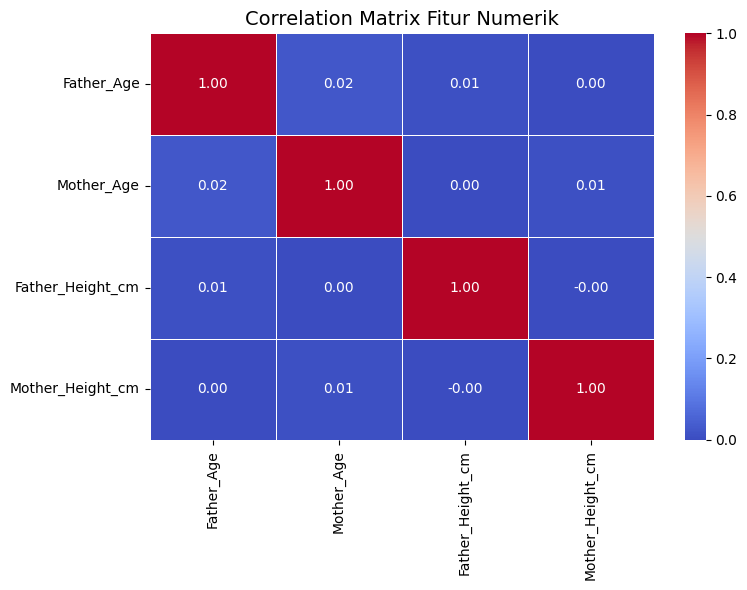

C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


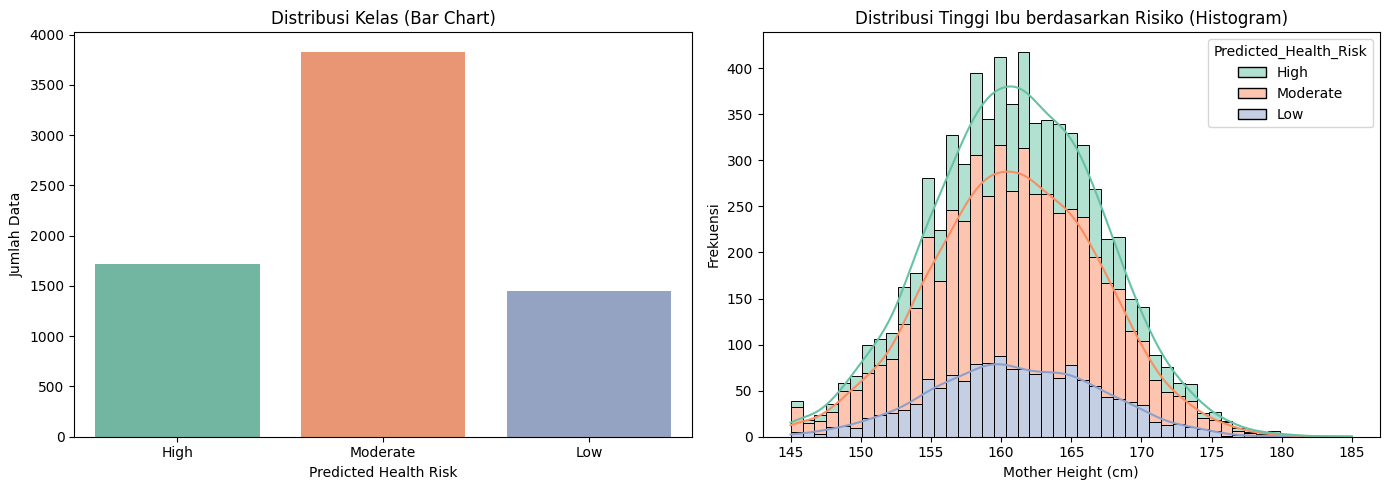

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


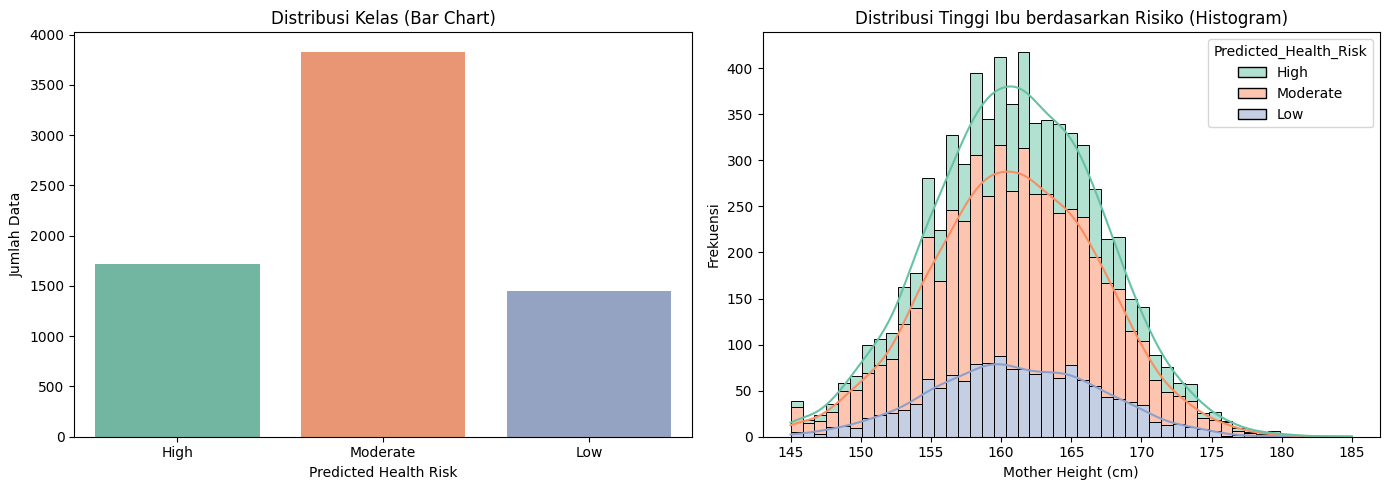

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


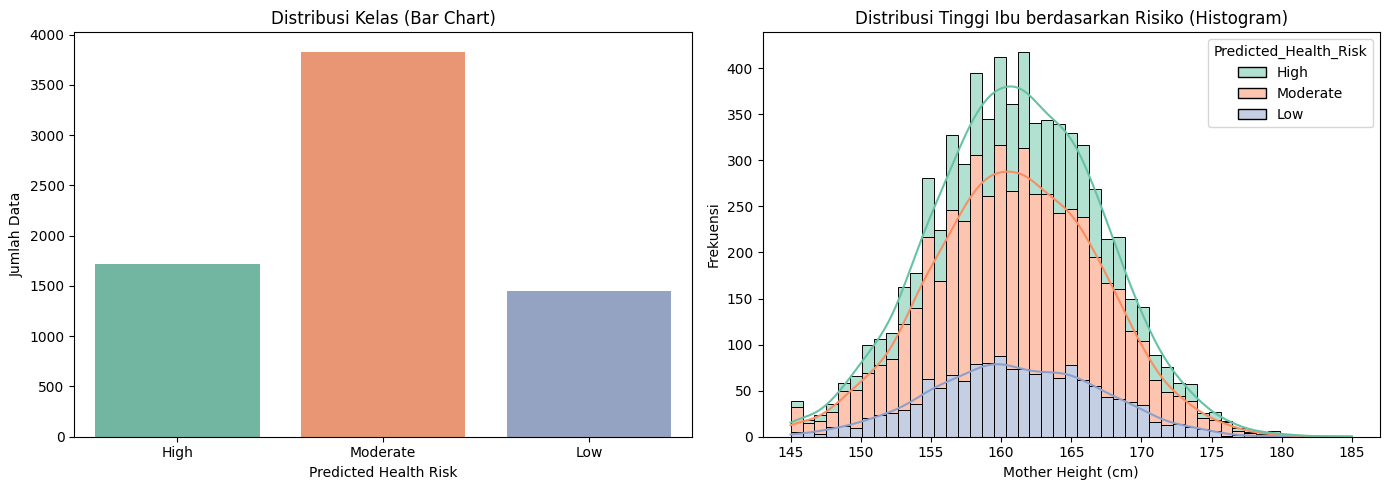

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


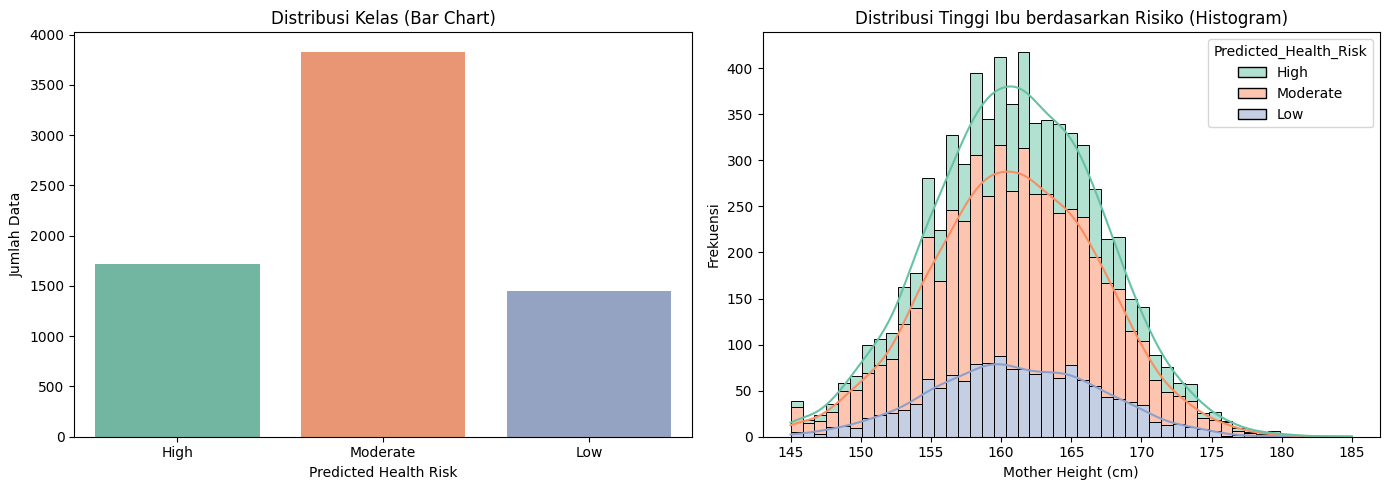

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


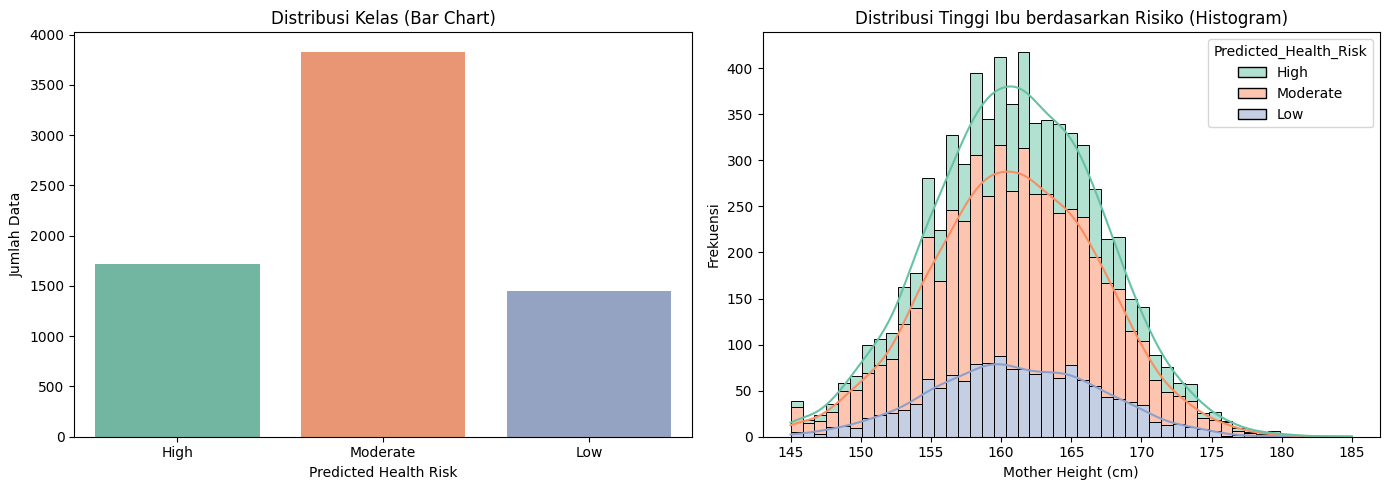

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


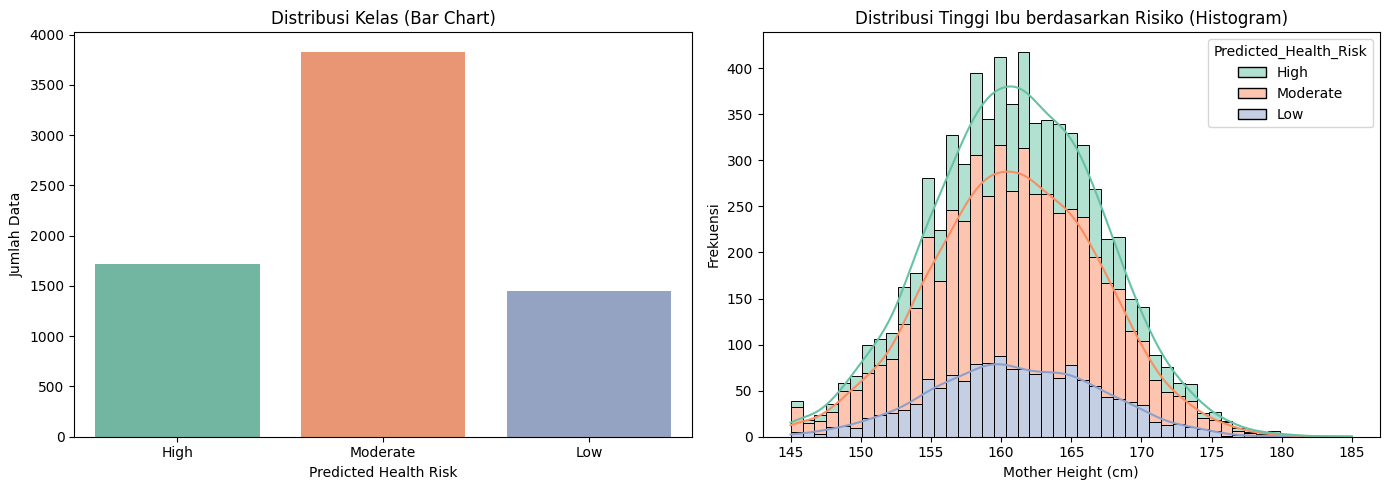

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


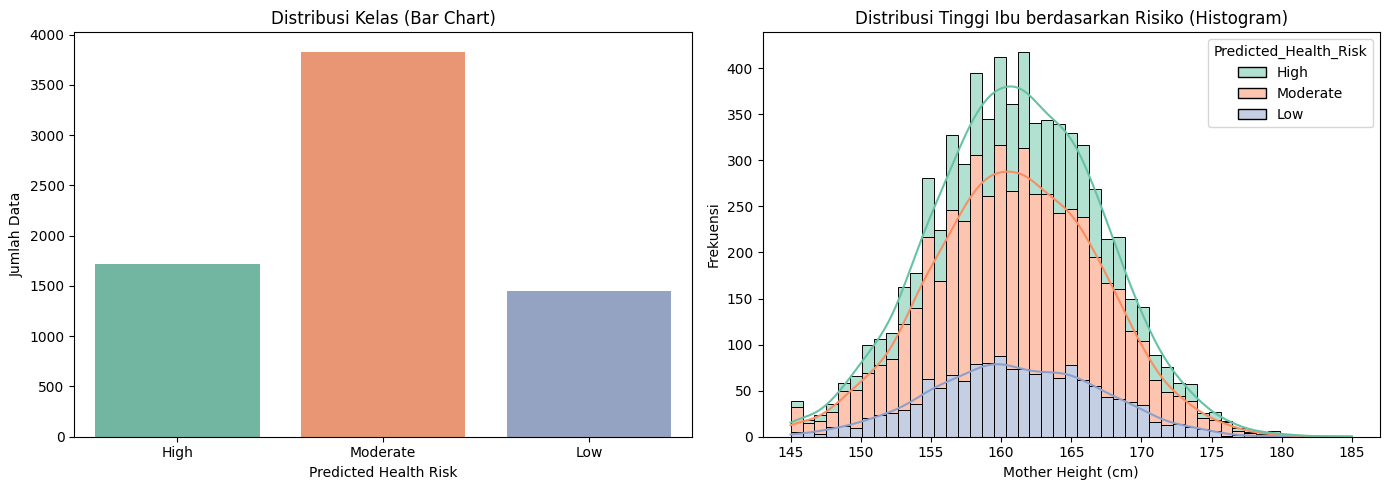

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


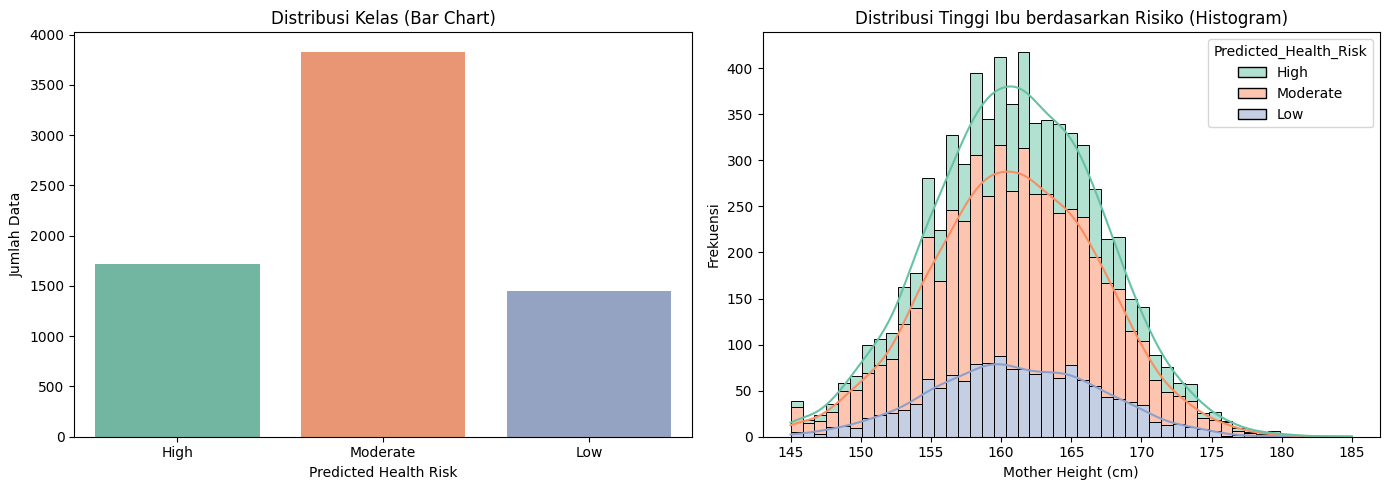

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


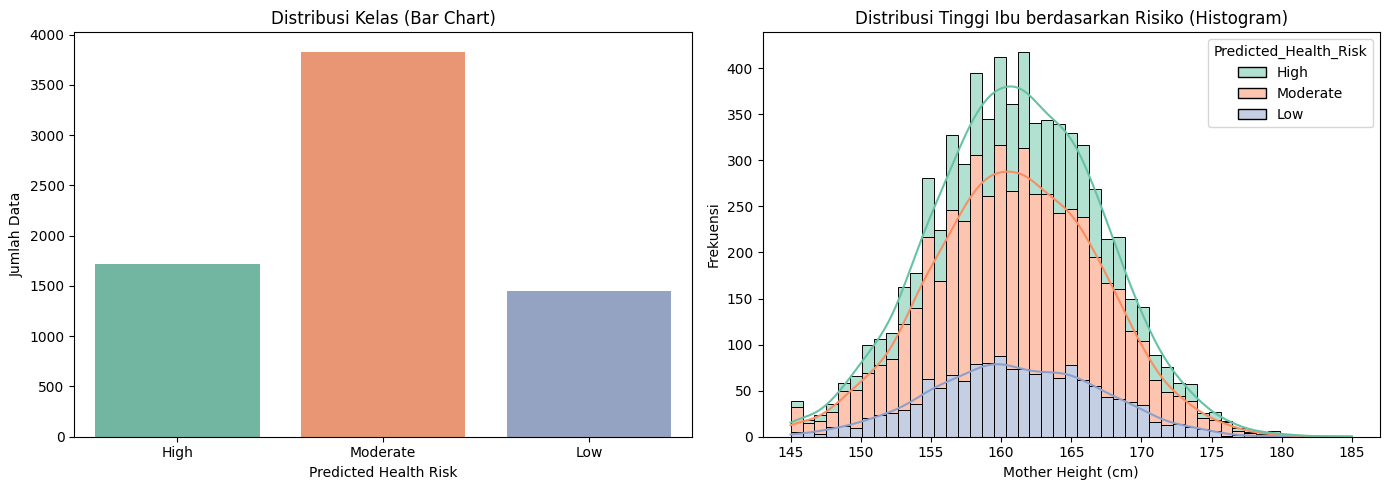

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


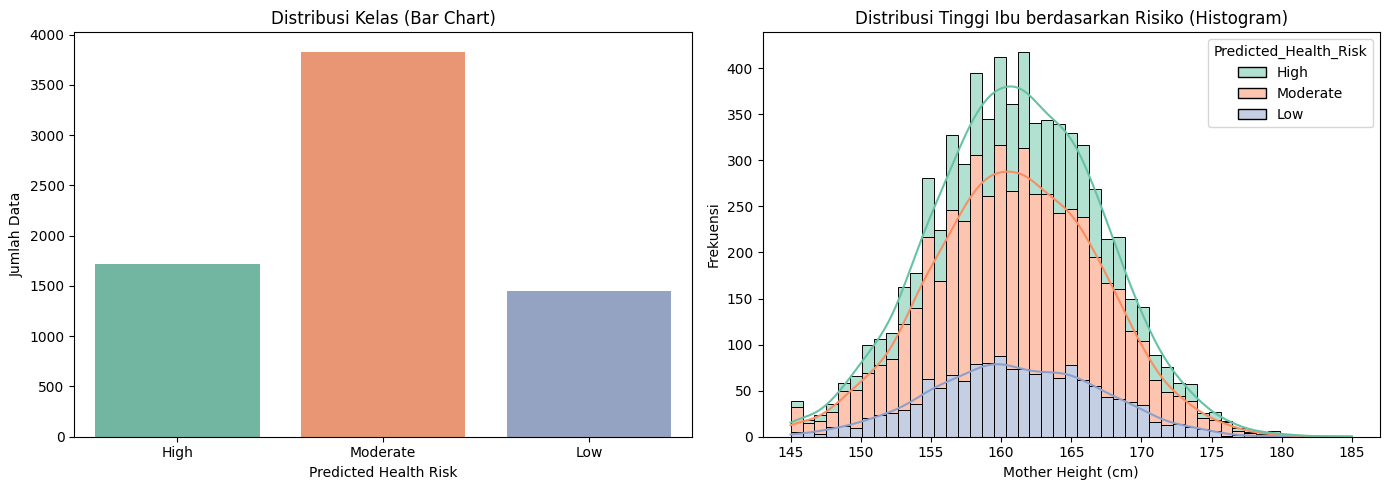

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


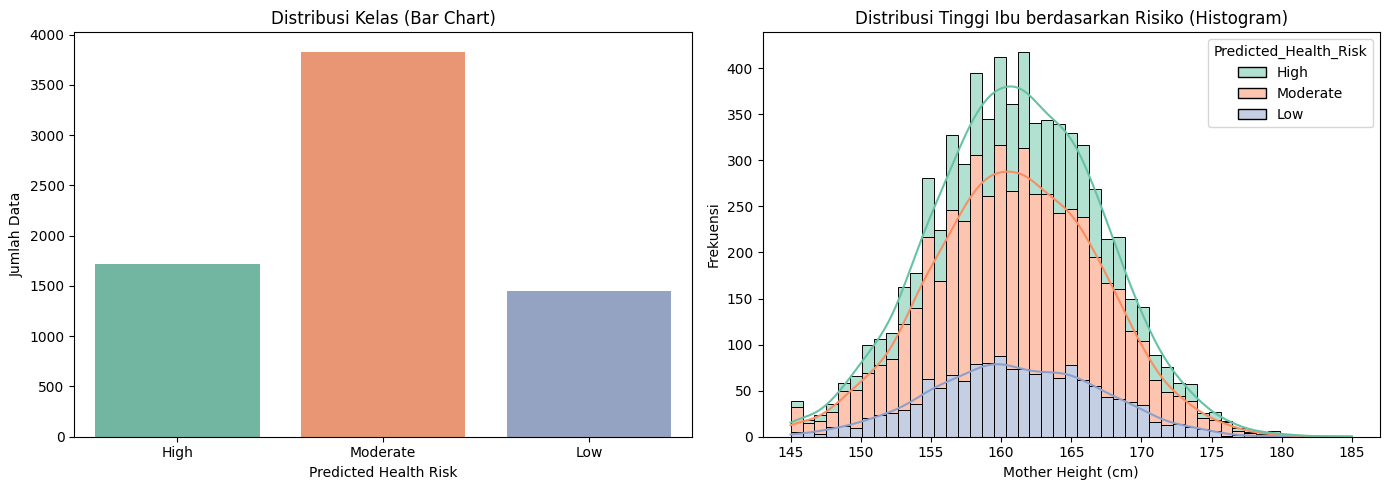

None


C:\Users\BetrisT\AppData\Local\Temp\ipykernel_24912\3800525820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')


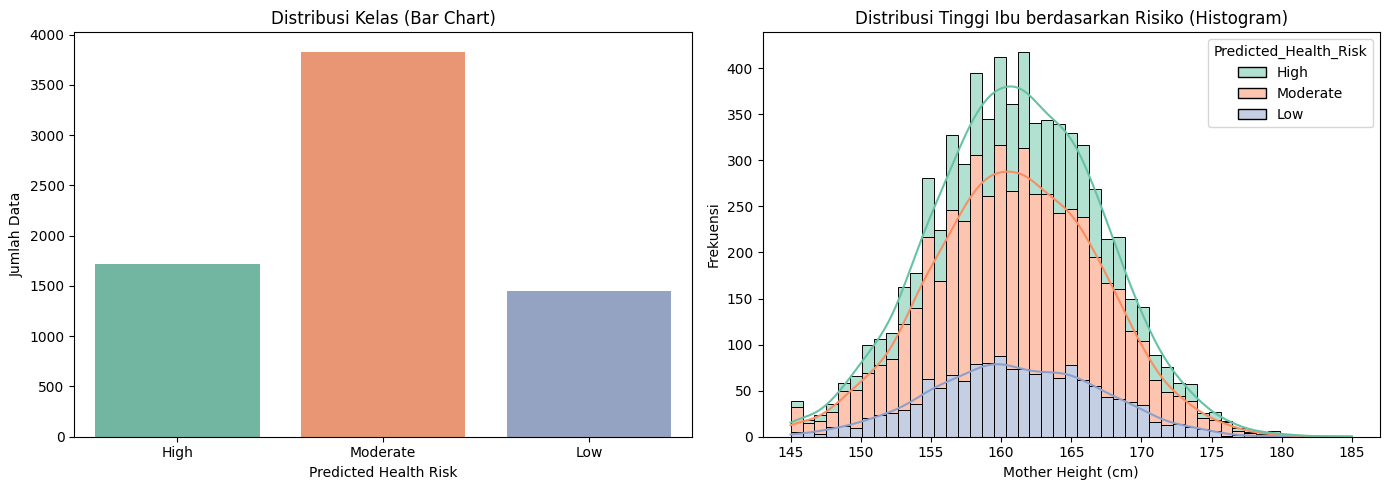

None


In [219]:
# --- 1. MEMBUAT CORRELATION MATRIX ---
plt.figure(figsize=(8, 6))

# Menghitung korelasi (hanya untuk kolom numerik)
# Jika Predicted_Health_Risk bertipe teks, ia otomatis diabaikan di matriks ini
corr_matrix = df[['Father_Age', 'Mother_Age', 'Father_Height_cm', 'Mother_Height_cm']].corr()

# Gambar Heatmap Korelasi
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()


for i in categoric:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Subplot 1: Bar Chart Jumlah Data berdasarkan Predicted_Health_Risk
    sns.countplot(x='Predicted_Health_Risk', data=df, ax=axes[0], palette='Set2')
    axes[0].set_title('Distribusi Kelas (Bar Chart)', fontsize=12)
    axes[0].set_xlabel('Predicted Health Risk')
    axes[0].set_ylabel('Jumlah Data')

    # Subplot 2: Histogram (Contoh: Distribusi Tinggi Ibu berdasarkan Kategori Risiko)
    # Kamu bisa mengganti 'Mother_Height_cm' dengan kolom numerik lain yang ingin dilihat
    sns.histplot(data=df, x='Mother_Height_cm', hue='Predicted_Health_Risk', 
                 kde=True, ax=axes[1], palette='Set2', multiple='stack')
    axes[1].set_title('Distribusi Tinggi Ibu berdasarkan Risiko (Histogram)', fontsize=12)
    axes[1].set_xlabel('Mother Height (cm)')
    axes[1].set_ylabel('Frekuensi')

    # Merapikan tata letak agar tidak tumpang tindih
    plt.tight_layout()
    print(plt.show())

### insights and problem :

- Found missing value in family disease history
- Some categoric value has a balance data (gender feature), but most of them also has imbalance data
- Remove family_id columns


# **Data Preprocessing**

In [220]:
df["Family_Disease_History"] = df["Family_Disease_History"].fillna("Unknown")

In [221]:
df_clean = df.copy()

df_clean = df_clean.drop("Family_ID", axis = 1)

# **Feature Engineering**

In [222]:
y = df_clean["Predicted_Health_Risk"]
x = df_clean.drop("Predicted_Health_Risk", axis = 1)

encode_tar = LabelEncoder()
y = encode_tar.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [223]:
x_test

,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Height_cm,Predicted_Child_Blood_Group
6500,54,34,178.5,165.2,A+,B-,Hazel,Hazel,Black,Brown,Medium,Olive,Multiple,Male,177.0,AB-
2944,32,29,171.0,156.2,B+,B+,Blue,Blue,Blonde,Black,Light,Light,Diabetes,Male,164.6,B+
2024,51,27,166.0,164.5,A+,B+,Brown,Hazel,Black,Black,Medium,Olive,Hypertension,Female,162.8,AB-
263,48,19,161.6,162.3,A+,O+,Blue,Brown,Blonde,Blonde,Medium,Fair,Asthma,Male,170.8,A-
4350,25,22,160.3,168.8,B+,O+,Gray,Hazel,Black,Black,Olive,Fair,Hypertension,Male,169.3,B+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5945,48,41,185.0,151.7,A-,B+,Green,Brown,Black,Blonde,Fair,Medium,Diabetes,Male,176.5,AB-
1630,44,32,176.1,166.3,O+,O+,Brown,Brown,Brown,Brown,Light,Light,Multiple,Female,166.1,O-
4043,24,40,182.8,152.6,B+,A+,Gray,Brown,Black,Black,Olive,Medium,Hypertension,Female,155.5,AB+
1881,49,44,160.5,159.9,A+,B+,Brown,Brown,Black,Black,Fair,Light,Diabetes,Female,151.4,AB-


In [224]:
encode = LabelEncoder()
scale = StandardScaler()

categoric.remove("Predicted_Health_Risk")

for i in categoric:
    x_train[i] = encode.fit_transform(x_train[i])
    x_test[i] = encode.transform(x_test[i])

for i in numeric:
    x_train[i] = scale.fit_transform(x_train[[i]])
    x_test[i] = scale.transform(x_test[[i]])

# **Modelling**

In [225]:
model_rf = RandomForestClassifier(n_estimators=100, max_depth= 10, min_samples_leaf= 5, random_state=42)

model_rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [226]:
model_log = LogisticRegression(C= 3, max_iter=100, random_state= 42)

model_log.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",3
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [227]:
model_xgb = XGBClassifier(n_estimators = 100, max_depth =5, learning_rate = 0.2)

model_xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

# **Evaluations**

========= LAPORAN KLASIFIKASI =========
              precision    recall  f1-score   support

           0       0.77      0.73      0.75       502
           1       0.75      0.67      0.71       429
           2       0.77      0.82      0.80      1169

    accuracy                           0.77      2100
   macro avg       0.76      0.74      0.75      2100
weighted avg       0.77      0.77      0.77      2100

Akurasi Total: 76.90%



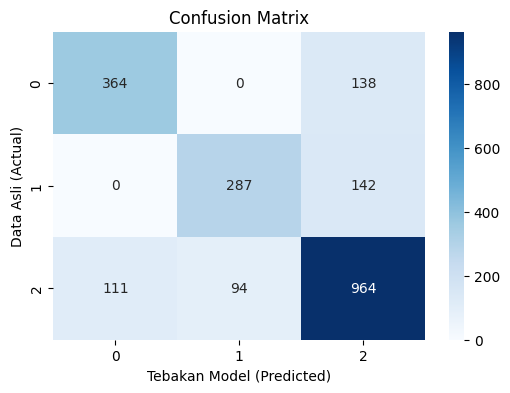

In [228]:
y_pred = model_xgb.predict(x_test)

# 2. Hitung dan cetak Laporan Klasifikasi (Precision, Recall, F1-Score)
print("========= LAPORAN KLASIFIKASI =========")
print(classification_report(y_test, y_pred))
print(f"Akurasi Total: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("=======================================\n")

# 3. Membuat dan menampilkan Confusion Matrix dalam bentuk gambar (Heatmap)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_xgb.classes_, 
            yticklabels=model_xgb.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Data Asli (Actual)')
plt.xlabel('Tebakan Model (Predicted)')
plt.show()

========= LAPORAN KLASIFIKASI =========
              precision    recall  f1-score   support

           0       0.63      0.39      0.48       502
           1       0.66      0.54      0.59       429
           2       0.66      0.81      0.72      1169

    accuracy                           0.65      2100
   macro avg       0.65      0.58      0.60      2100
weighted avg       0.65      0.65      0.64      2100

Akurasi Total: 65.19%



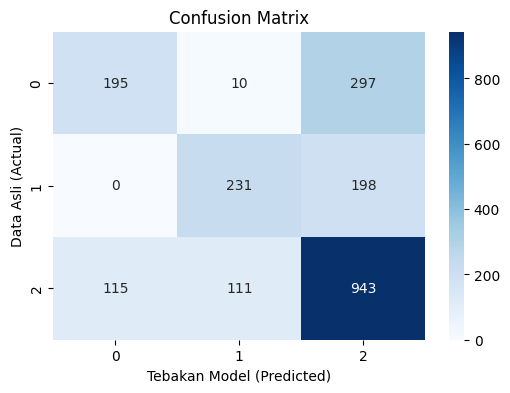

In [229]:
y_pred = model_log.predict(x_test)

# 2. Hitung dan cetak Laporan Klasifikasi (Precision, Recall, F1-Score)
print("========= LAPORAN KLASIFIKASI =========")
print(classification_report(y_test, y_pred))
print(f"Akurasi Total: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("=======================================\n")

# 3. Membuat dan menampilkan Confusion Matrix dalam bentuk gambar (Heatmap)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_log.classes_, 
            yticklabels=model_log.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Data Asli (Actual)')
plt.xlabel('Tebakan Model (Predicted)')
plt.show()

========= LAPORAN KLASIFIKASI =========
              precision    recall  f1-score   support

           0       0.84      0.64      0.72       502
           1       0.82      0.58      0.68       429
           2       0.74      0.90      0.81      1169

    accuracy                           0.77      2100
   macro avg       0.80      0.70      0.74      2100
weighted avg       0.78      0.77      0.76      2100

Akurasi Total: 77.10%



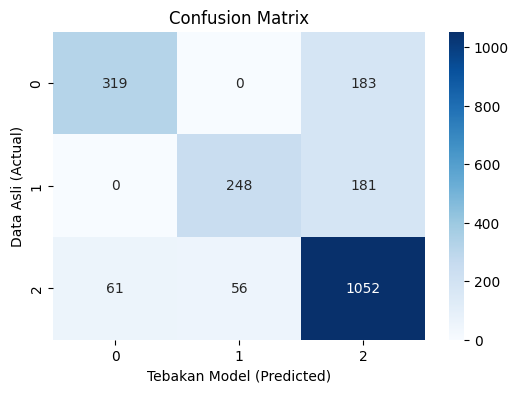

In [230]:
y_pred = model_rf.predict(x_test)

# 2. Hitung dan cetak Laporan Klasifikasi (Precision, Recall, F1-Score)
print("========= LAPORAN KLASIFIKASI =========")
print(classification_report(y_test, y_pred))
print(f"Akurasi Total: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("=======================================\n")

# 3. Membuat dan menampilkan Confusion Matrix dalam bentuk gambar (Heatmap)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_rf.classes_, 
            yticklabels=model_rf.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Data Asli (Actual)')
plt.xlabel('Tebakan Model (Predicted)')
plt.show()